In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person1230_virus_2081.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person466_virus_960.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person114_virus_217.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person1197_virus_2039.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person1489_virus_2594.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person41_bacteria_209.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person909_virus_1565.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person1065_bacteria_2999.jpeg
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA/person567_bacteria_2353.jpeg
/kaggle/input/datasets/assem

In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    if len(filenames) > 0:
        print("Files:", filenames[:5])

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/assemelqirsh
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA
Files: ['person1230_virus_2081.jpeg', 'person466_virus_960.jpeg', 'person114_virus_217.jpeg', 'person1197_virus_2039.jpeg', 'person1489_virus_2594.jpeg']
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/NORMAL
Files: ['NORMAL2-IM-0336-0001.jpeg', 'NORMAL2-IM-1294-0001-0002.jpeg', 'IM-0421-0001.jpeg', 'NORMAL2-IM-0416-0001-0002.jpeg', 'NORMAL2-IM-0696-0001.jpeg']
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/PNEUMONIA
Files: ['person746_virus_1369.jpeg', 'person399_bacteria_1805.jpeg', 'person622_bacteria_2494.jpeg', 'person412

In [8]:
print(os.listdir("/kaggle/input/datasets/assemelqirsh"))

['chest-x-ray-dataset']


In [9]:
for dirname, _, filenames in os.walk("/kaggle/input/datasets/assemelqirsh"):
    print(dirname)

/kaggle/input/datasets/assemelqirsh
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_bicubic
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_

In [11]:
DATA_DIR = "/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray"

print(os.listdir(DATA_DIR))

['val', 'test', 'train']


In [12]:
for split in ["train", "test", "val"]:
    path = os.path.join(DATA_DIR, split)
    
    print("\n", split.upper())
    print(os.listdir(path))


 TRAIN
['PNEUMONIA', 'NORMAL']

 TEST
['PNEUMONIA', 'NORMAL']

 VAL
['PNEUMONIA', 'NORMAL']


In [13]:
for split in ["train", "test", "val"]:
    
    print("\n", split.upper())
    
    for label in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(DATA_DIR, split, label)
        
        images = [
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]
        
        print(label, ":", len(images))


 TRAIN
NORMAL : 1266
PNEUMONIA : 3418

 TEST
NORMAL : 159
PNEUMONIA : 428

 VAL
NORMAL : 158
PNEUMONIA : 427


In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random

In [18]:
train_path = os.path.join(DATA_DIR, "train")

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

print("Normal images:", len(os.listdir(normal_path)))
print("Pneumonia images:", len(os.listdir(pneumonia_path)))

Normal images: 1266
Pneumonia images: 3418


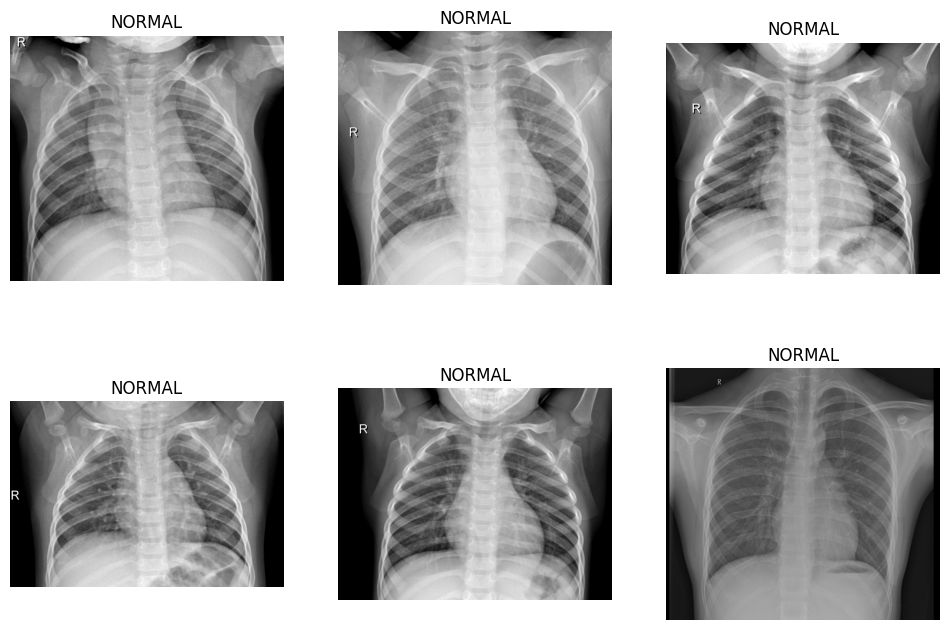

In [19]:
plt.figure(figsize = (12,8))
images = random.sample(os.listdir(normal_path),6)
for i,img_name in enumerate(images):
    img = Image.open(os.path.join(normal_path,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap = 'gray')
    plt.title('NORMAL')
    plt.axis('off')
plt.show()

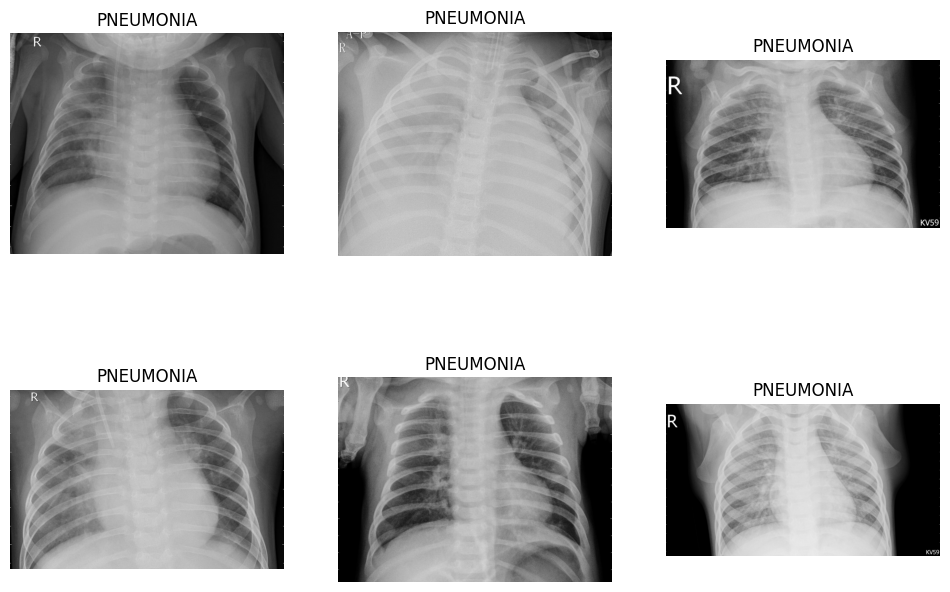

In [21]:
plt.figure(figsize=(12,8))
images = random.sample(os.listdir(pneumonia_path),6)

for i,img_name in enumerate(images):
    img = Image.open(os.path.join(pneumonia_path,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis('off')
plt.show()

In [22]:
sample_image = os.listdir(normal_path)[0]

img = Image.open(
    os.path.join(normal_path,sample_image)
)

print("Image size:", img.size)
print("Image mode:", img.mode)

'''L = grayscale image
    1 channel'''

Image size: (1336, 1128)
Image mode: L


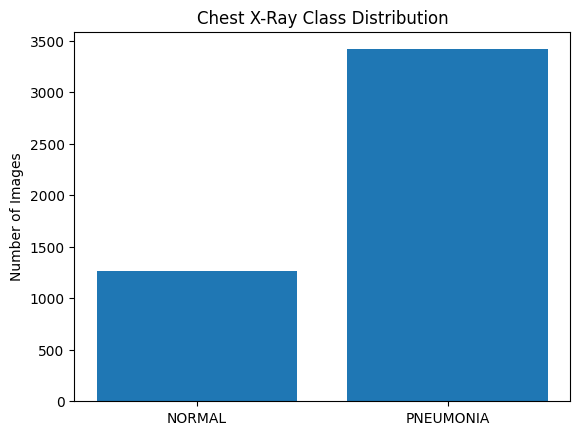

In [23]:
classes = ["NORMAL","PNEUMONIA"]

counts = [
    len(os.listdir(normal_path)),
    len(os.listdir(pneumonia_path))
]


plt.bar(classes,counts)

plt.title("Chest X-Ray Class Distribution")
plt.ylabel("Number of Images")

plt.show()

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,BatchNormalization
from tensorflow.keras.activations import relu,sigmoid
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [28]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"train"),
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    color_mode = 'grayscale',
    label_mode = 'binary',
    shuffle=True
)

Found 4684 files belonging to 2 classes.


I0000 00:00:1786106244.357511      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786106244.360382      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [30]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

Found 585 files belonging to 2 classes.


In [31]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

Found 587 files belonging to 2 classes.


In [32]:
print(train_ds.class_names)

['NORMAL', 'PNEUMONIA']


In [33]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

val_ds = val_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

test_ds = test_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

In [34]:
AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [35]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 1)
Label shape: (32, 1)


In [40]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (224,224,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation = 'relu'),
    Dropout(0.5),

    Dense(1,activation = 'sigmoid')
    
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,409 (42.61 MB)

 Trainable params: 11,168,961 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [43]:
history = model.fit(train_ds,validation_data = val_ds,epochs = 15)

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9351 - loss: 0.1933 - val_accuracy: 0.9385 - val_loss: 0.2400
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9466 - loss: 0.1663 - val_accuracy: 0.8188 - val_loss: 0.7644
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9445 - loss: 0.1798 - val_accuracy: 0.5145 - val_loss: 1.5163
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9428 - loss: 0.1635 - val_accuracy: 0.9111 - val_loss: 0.3059
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9400 - loss: 0.1602 - val_accuracy: 0.8769 - val_loss: 0.5106
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9483 - loss: 0.1575 - val_accuracy: 0.9282 - val_loss: 0.3048
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9483 - loss: 0.1612 - val_accuracy: 0.9419 - val_loss: 0.1585
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9564 - loss: 0.1398 - 

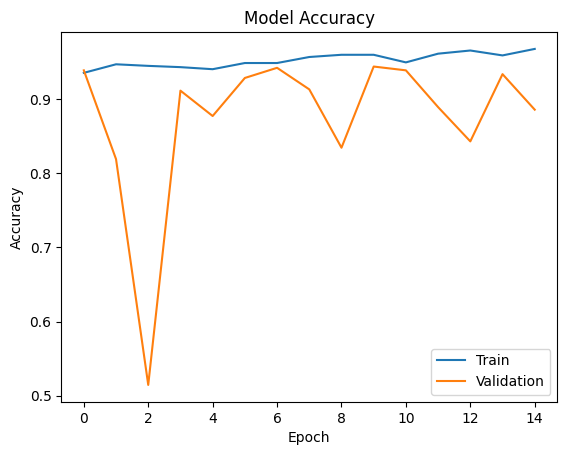

In [45]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    ["Train","Validation"]
)

plt.show()

In [46]:
model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9097 - loss: 0.2593


[0.25926312804222107, 0.9097104072570801]

In [47]:
model.evaluate(val_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8855 - loss: 0.3395


[0.33951839804649353, 0.8854700922966003]

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step


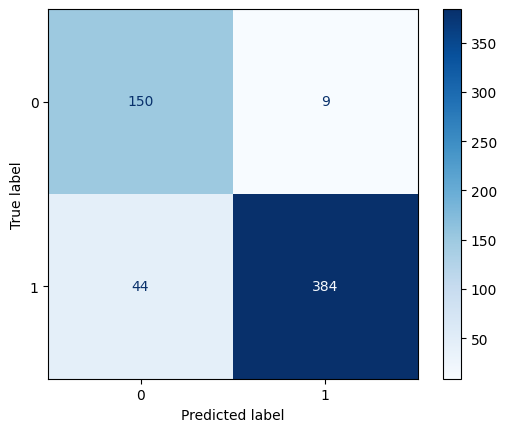

In [49]:
predictions = model.predict(test_ds)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)
actual_labels = []

for images, labels in test_ds:
    actual_labels.extend(labels.numpy())


actual_labels = np.array(actual_labels).reshape(-1)
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = "Blues")
plt.show()


In [50]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["NORMAL","PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.77      0.94      0.85       159
   PNEUMONIA       0.98      0.90      0.94       428

    accuracy                           0.91       587
   macro avg       0.88      0.92      0.89       587
weighted avg       0.92      0.91      0.91       587

